In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, LinearRegression


In [34]:
honey = pd.read_csv('honey.csv', sep=";")
weather = pd.read_csv('df_weekly_2019_2025.csv')
beehives = pd.read_csv('ule.csv', sep=";")

In [35]:
honey.head()

,year,week,honey,harvest
0,2019,30,66.0,1
1,2019,32,55.0,1
2,2019,33,134.0,2
3,2019,34,72.0,1
4,2019,35,59.0,1


In [36]:
beehives.head()

,year,beehive
0,2019,92
1,2020,86
2,2021,98
3,2022,100
4,2023,87


In [37]:
weather.head()

,year,week,temp,wspd,prcp,pres
0,2019,18,8.644572,2.952617,0.247276,940.72546
1,2019,19,8.801729,2.939627,0.163314,946.07404
2,2019,20,10.284056,2.588411,0.200703,949.08860
3,2019,21,13.292661,2.689059,0.371334,943.73720
4,2019,22,14.097325,2.743598,0.164248,950.88153


In [38]:
df = pd.merge(honey, weather, on=["year", "week"], how="inner")

In [39]:
df = pd.merge(df, beehives, on="year", how="inner")

In [40]:
weather_filtered = weather[(weather['week'] >= 18) & (weather['week'] <= 30)]

weather_filtered['feature_week'] = weather_filtered['week'].astype(str) + '_'
weather_pivot = weather_filtered.pivot_table(
    index='year',
    columns='feature_week',
    values=['temp', 'wspd', 'prcp', 'pres']
)

weather_pivot.columns = [f'{col[0]}_{col[1].replace("_", "")}' for col in weather_pivot.columns]

df = pd.merge(df, weather_pivot, on='year', how='left')
df.head()

/tmp/ipykernel_8349/65519405.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_filtered['feature_week'] = weather_filtered['week'].astype(str) + '_'


,year,week,honey,harvest,temp,wspd,prcp,pres,beehive,prcp_18,...,wspd_21,wspd_22,wspd_23,wspd_24,wspd_25,wspd_26,wspd_27,wspd_28,wspd_29,wspd_30
0,2019,30,66.0,1,18.468962,2.068542,0.125877,949.43176,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
1,2019,32,55.0,1,19.387705,1.972191,0.171244,948.63810,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
2,2019,33,134.0,2,16.821316,1.924085,0.108202,949.98334,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
3,2019,34,72.0,1,18.534908,1.906017,0.032221,957.32385,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
4,2019,35,59.0,1,20.576923,1.698392,0.071077,954.63135,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542


In [41]:
df.columns

Index(['year', 'week', 'honey', 'harvest', 'temp', 'wspd', 'prcp', 'pres',
       'beehive', 'prcp_18', 'prcp_19', 'prcp_20', 'prcp_21', 'prcp_22',
       'prcp_23', 'prcp_24', 'prcp_25', 'prcp_26', 'prcp_27', 'prcp_28',
       'prcp_29', 'prcp_30', 'pres_18', 'pres_19', 'pres_20', 'pres_21',
       'pres_22', 'pres_23', 'pres_24', 'pres_25', 'pres_26', 'pres_27',
       'pres_28', 'pres_29', 'pres_30', 'temp_18', 'temp_19', 'temp_20',
       'temp_21', 'temp_22', 'temp_23', 'temp_24', 'temp_25', 'temp_26',
       'temp_27', 'temp_28', 'temp_29', 'temp_30', 'wspd_18', 'wspd_19',
       'wspd_20', 'wspd_21', 'wspd_22', 'wspd_23', 'wspd_24', 'wspd_25',
       'wspd_26', 'wspd_27', 'wspd_28', 'wspd_29', 'wspd_30'],
      dtype='object')

In [42]:
df.head()

,year,week,honey,harvest,temp,wspd,prcp,pres,beehive,prcp_18,...,wspd_21,wspd_22,wspd_23,wspd_24,wspd_25,wspd_26,wspd_27,wspd_28,wspd_29,wspd_30
0,2019,30,66.0,1,18.468962,2.068542,0.125877,949.43176,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
1,2019,32,55.0,1,19.387705,1.972191,0.171244,948.63810,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
2,2019,33,134.0,2,16.821316,1.924085,0.108202,949.98334,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
3,2019,34,72.0,1,18.534908,1.906017,0.032221,957.32385,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
4,2019,35,59.0,1,20.576923,1.698392,0.071077,954.63135,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542


In [43]:
train = df[df["year"] <= 2023]
test = df[df["year"] >= 2024]

In [44]:
# features = ["temp", "wspd", "prcp", "pres", "beehive", "harvest"]

In [45]:
features = [col for col in df.columns if col != 'honey']
print(features)

['year', 'week', 'harvest', 'temp', 'wspd', 'prcp', 'pres', 'beehive', 'prcp_18', 'prcp_19', 'prcp_20', 'prcp_21', 'prcp_22', 'prcp_23', 'prcp_24', 'prcp_25', 'prcp_26', 'prcp_27', 'prcp_28', 'prcp_29', 'prcp_30', 'pres_18', 'pres_19', 'pres_20', 'pres_21', 'pres_22', 'pres_23', 'pres_24', 'pres_25', 'pres_26', 'pres_27', 'pres_28', 'pres_29', 'pres_30', 'temp_18', 'temp_19', 'temp_20', 'temp_21', 'temp_22', 'temp_23', 'temp_24', 'temp_25', 'temp_26', 'temp_27', 'temp_28', 'temp_29', 'temp_30', 'wspd_18', 'wspd_19', 'wspd_20', 'wspd_21', 'wspd_22', 'wspd_23', 'wspd_24', 'wspd_25', 'wspd_26', 'wspd_27', 'wspd_28', 'wspd_29', 'wspd_30']


In [46]:
X_train = train[features]
y_train = train["honey"]

X_test = test[features]
y_test = test["honey"]

In [47]:
# najlepszy
model = Ridge(
    alpha=10.0
)

In [48]:
# model = RandomForestRegressor(
#     n_estimators=300,
#     random_state=42
# )

In [49]:
model.fit(X_train, y_train)

Ridge(alpha=10.0)

In [50]:
y_pred = model.predict(X_test)

In [51]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 27.357990223933875
RMSE: 35.53604986967676


In [52]:
results = test.copy()
results["predicted_honey"] = y_pred

print(results[["year", "week", "honey", "predicted_honey"]])

    year  week  honey  predicted_honey
33  2024    27  126.7       113.548847
34  2024    28   45.5        74.433521
35  2024    30  134.4       120.865821
36  2024    31   72.8       128.709522
37  2024    32  105.0       129.730574
38  2024    33   65.8        98.796326
39  2024    34  100.1       125.308884
40  2024    35   53.9       136.364518
41  2024    37  148.4       152.117220
42  2025    28  126.7       120.643196
43  2025    31  191.1       189.740373
44  2025    33   42.0       101.012220
45  2025    35  109.9       132.528040
46  2025    36  217.0       203.690725


In [53]:
real_test_honey = sum(test["honey"])
predicted_honey_sum = sum(results["predicted_honey"])
print(predicted_honey_sum - real_test_honey)

288.18978832560447


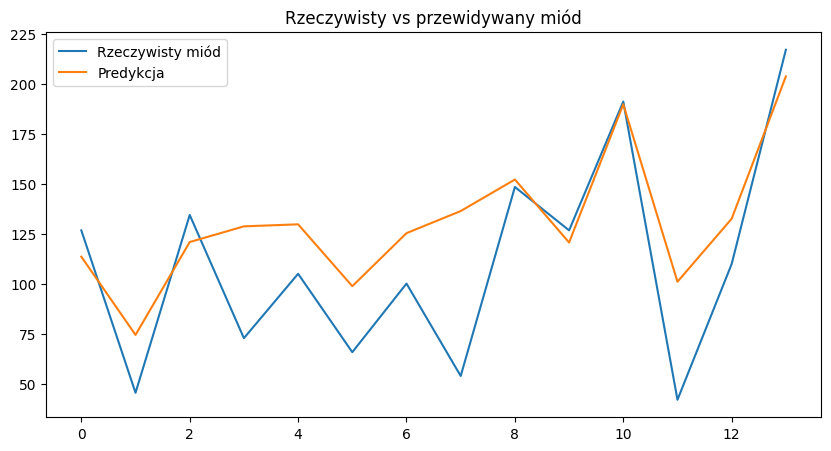

In [54]:
plt.figure(figsize=(10,5))
plt.plot(results["honey"].values, label="Rzeczywisty miód")
plt.plot(results["predicted_honey"].values, label="Predykcja")
plt.legend()
plt.title("Rzeczywisty vs przewidywany miód")
plt.show()

In [55]:
model = XGBRegressor(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    min_child_weight=5,
    subsample=0.6,
    colsample_bytree=0.6,
    reg_alpha=1.0,
    reg_lambda=5.0,
    gamma=1.0,
    random_state=42
)

model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=1.0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

In [56]:
y_pred = model.predict(X_test)

In [57]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 41.19610018048968
RMSE: 46.768604915657676


In [58]:
results = test.copy()
results["predicted_honey"] = y_pred

print(results[["year", "week", "honey", "predicted_honey"]].head())

    year  week  honey  predicted_honey
33  2024    27  126.7       138.712830
34  2024    28   45.5       120.364204
35  2024    30  134.4       109.426773
36  2024    31   72.8       135.078384
37  2024    32  105.0       132.280243


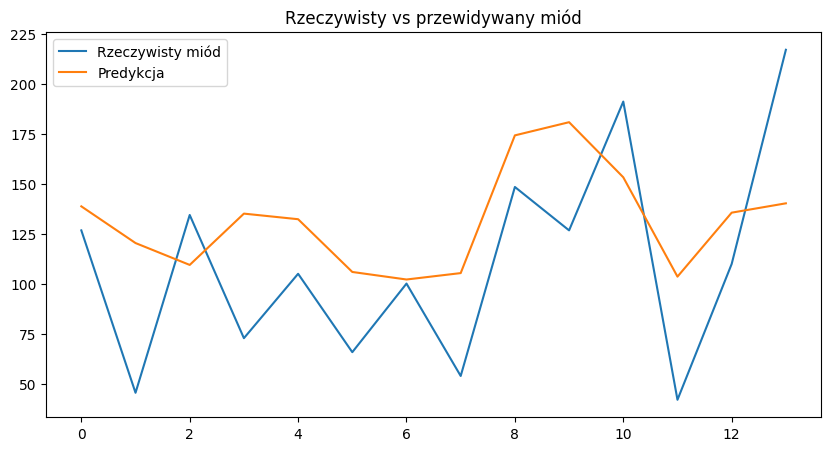

In [59]:
plt.figure(figsize=(10,5))
plt.plot(results["honey"].values, label="Rzeczywisty miód")
plt.plot(results["predicted_honey"].values, label="Predykcja")
plt.legend()
plt.title("Rzeczywisty vs przewidywany miód")
plt.show()

In [60]:
real_test_honey = sum(test["honey"])
predicted_honey_sum = sum(results["predicted_honey"])
print(predicted_honey_sum - real_test_honey)

297.53354949951176


In [61]:
corr = df.corr()
honey_corr = corr["honey"].sort_values(ascending=False)

honey_corr

,honey
honey,1.000000
harvest,0.526461
prcp,0.409763
wspd,0.380275
prcp_26,0.311182
...,...
temp_23,-0.246829
temp_21,-0.252554
wspd_27,-0.268982
temp_22,-0.290444
